### Imports

In [33]:
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.psf import PSF
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel

from dolphin.processor.config import ModelConfig
from dolphin.processor import Processor
from dolphin.analysis.output import Output
from dolphin.analysis import auto_source_grid_from_caustics, plot_caustics_and_source_grid

In [34]:
processor = Processor("../io_directory_example/")

lens_name = "lens_system2"
model_id = "example"
reconstruction_id = "recon_v3"

In [35]:
# processor.swim(lens_name=lens_name, model_id=model_id, log=False)

In [36]:
output = Output("../io_directory_example/")
output.load_output(lens_name=lens_name, model_id=model_id)

grid_half_width = 0.8  # arcsec, adjust as needed
pixel_size = 0.04  # arcsec
grid_pixels = int((grid_half_width * 2) / pixel_size)
source_grid_kwargs = {
    'pixel_width': pixel_size,
    'num_pixels_x': grid_pixels,
    'num_pixels_y': grid_pixels,
    'ra_at_xy_0': - (grid_pixels // 2 ) * pixel_size,
    'dec_at_xy_0': - (grid_pixels // 2 ) * pixel_size,
}
pprint(source_grid_kwargs)

{'dec_at_xy_0': -0.8,
 'num_pixels_x': 40,
 'num_pixels_y': 40,
 'pixel_width': 0.04,
 'ra_at_xy_0': -0.8}


In [37]:
regularization_kwargs = {
    "type": "curvature",
    "lambda_bounds": [1e3, 1e7],
    "lambda_tolerance": 1e-7,
    "max_iterations": 100,
}

In [38]:
result = processor.reconstruct_source(lens_name=lens_name, model_id=model_id, reconstruction_id=reconstruction_id, source_grid_kwargs=source_grid_kwargs, regularization_kwargs=regularization_kwargs)

Starting pixelated source reconstruction for lens_system2
Using lens model from: example
Source grid: 40 x 40 pixels
Pixel width: 0.0400 arcsec
Computing M matrix and b vector...
number of source pixels: 1600 (x axis: 40 pixels;  y axis: 40 pixels)
likelihood method: diagonal
Step 1: Lensing the source pixels
Step 1: Finished!
Step 2: Convolve the lensed pixels


Step 2: Finished!
Step 3: Compute the matrix M and vector b (vectorized)
Step 3: Finished!
Generating curvature regularization matrix...
M matrix diagnostics:
  Condition number: 4.26e+04
  Min eigenvalue: 1.27e+02
  Max eigenvalue: 5.41e+06
  Rank deficiency: 0 near-zero eigenvalues
Solving for optimal regularization strength...
  Testing derivative at different λ values:
    λ=1e+04: d(log evi)/dλ = -0.030752
    λ=1e+06: d(log evi)/dλ = -0.000825
    λ=1e+08: d(log evi)/dλ = -0.000026
  Derivative at lower bound (1e+03): -0.658015
  Derivative at upper bound (1e+07): -0.000164
Retrying with expanded bounds: [1.00e+01, 1.00e+09]
Success with expanded bounds! Optimal λ: 4.86e+01
Optimal λ: 4.86e+01
Solving for source pixel values...
Source image statistics:
  Shape: (40, 40)
  Min/Max: -1.224085e-01 / 1.965871e-01
  Sum: 7.397583e+00
  Mean: 4.623490e-03
Saved source image to /grad/bwedig/dolphin/notebooks/source_image.npy
Computed lens light model for source reconstruction.
Generatin

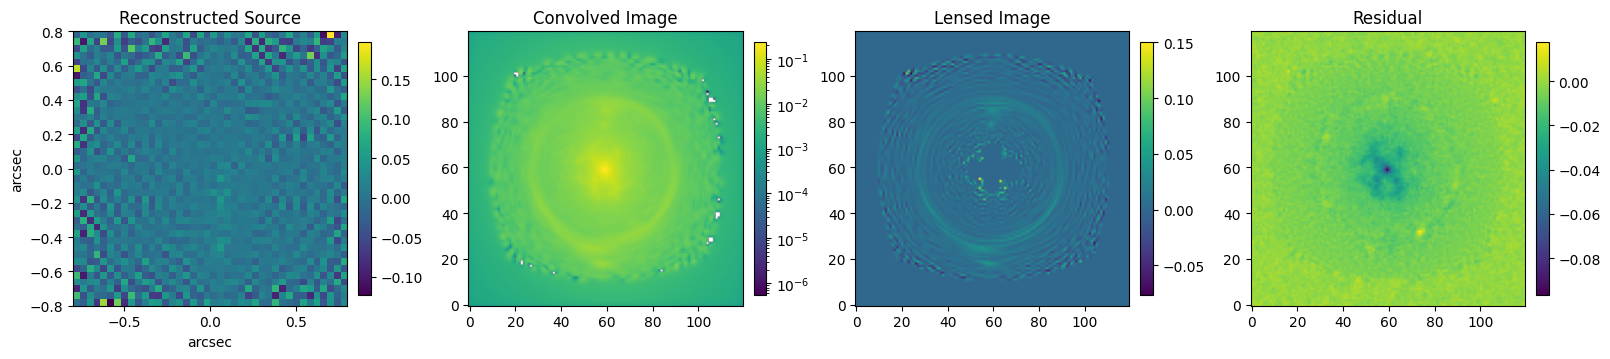

In [39]:
result = output.load_reconstruction_output(lens_name=lens_name, reconstruction_id=reconstruction_id,)

_, ax = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

im0 = ax[0].imshow(result["source_image"], origin='lower', extent=[-grid_half_width, grid_half_width, -grid_half_width, grid_half_width])
ax[0].set_title("Reconstructed Source")
ax[0].set_xlabel("arcsec")
ax[0].set_ylabel("arcsec")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(result["convolved_image"], origin='lower', norm=LogNorm())
ax[1].set_title("Convolved Image")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(result["lensed_image"], origin='lower')
ax[2].set_title("Lensed Image")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(result["residual"], origin='lower')
ax[3].set_title("Residual")
plt.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

plt.show()

In [ ]:
config = ModelConfig(
    lens_name=lens_name,
    file_system=output,
    settings=output._model_settings,
)

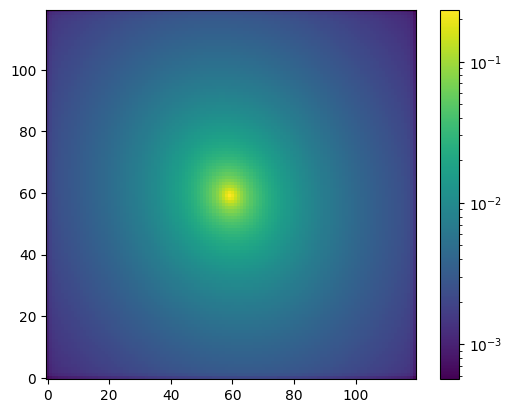

In [ ]:
lens_light_model_class = LightModel(config.get_lens_light_model_list())
lens_model_class = LensModel(config.get_lens_model_list())
source_model_class = LightModel(config.get_source_light_model_list())

kwargs_lens_light = output.kwargs_result["kwargs_lens_light"]

band_data = output._multi_band_list_out[0]

kwargs_data = band_data[0]
kwargs_psf = band_data[1]
psf_class = PSF(**kwargs_psf)

# Get pixel coordinates
nx, ny = kwargs_data["image_data"].shape
transform = kwargs_data.get(
    "transform_pix2angle"
)
ra_0 = kwargs_data.get("ra_at_xy_0", 0)
dec_0 = kwargs_data.get("dec_at_xy_0", 0)

# Create coordinate grid
x_grid, y_grid = np.meshgrid(np.arange(nx), np.arange(ny))
ra_grid = ra_0 + transform[0, 0] * x_grid + transform[0, 1] * y_grid
dec_grid = dec_0 + transform[1, 0] * x_grid + transform[1, 1] * y_grid

lens_plane_pixel_grid = PixelGrid(
    nx=nx,
    ny=ny,
    transform_pix2angle=transform,
    ra_at_xy_0=ra_0,
    dec_at_xy_0=dec_0,
)

image_model = ImageModel(data_class=lens_plane_pixel_grid,
                        psf_class=psf_class,
                        lens_model_class=lens_model_class,
                    #  source_model_class=source_model_class,
                        lens_light_model_class=lens_light_model_class,
                    #  kwargs_numerics=kwargs_numerics
                        )
lens_convolved = image_model.lens_surface_brightness(kwargs_lens_light=kwargs_lens_light, unconvolved=False) 

plt.imshow(lens_convolved, origin='lower', norm=LogNorm())
plt.colorbar()
plt.show()

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


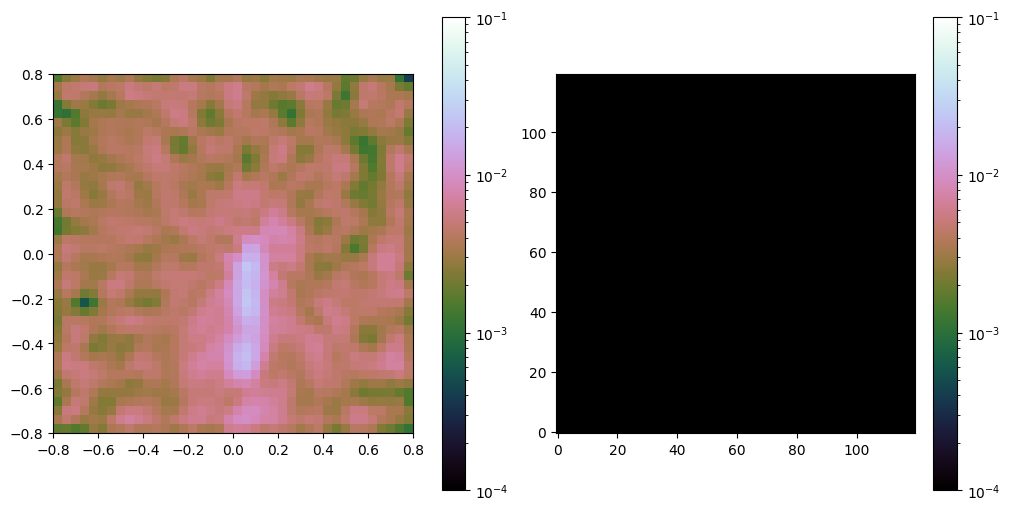

In [ ]:
source_image = np.load('/grad/bwedig/dolphin/notebooks/source_image.npy')
kwargs_source = [{
    # 'amp': 1, 
    'image': source_image,
    'scale': pixel_size
    }
]
source_model_class = LightModel(['INTERPOL'])

# rayshoot with lenstronomy
image_model = ImageModel(data_class=lens_plane_pixel_grid,
                            psf_class=psf_class,
                            lens_model_class=lens_model_class,
                            source_model_class=source_model_class,
                            lens_light_model_class=lens_light_model_class,
                        #  kwargs_numerics=kwargs_numerics
                            )
lensed_image = image_model.image(kwargs_lens=kwargs_lens,
                                kwargs_source=kwargs_source,
                               kwargs_lens_light=kwargs_lens_light,
                                unconvolved=True, 
                                lens_light_add=False, 
                                )

import scipy.signal
source_convolved = scipy.signal.fftconvolve(
    lensed_image, psf_class.kernel_point_source, mode="same"
)

_, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
im0 = ax[0].imshow(source_image, origin='lower', extent=[-grid_half_width, grid_half_width, -grid_half_width, grid_half_width], cmap='cubehelix', norm=LogNorm(vmin=1e-4, vmax=1e-1))
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(source_convolved, origin='lower', norm=LogNorm(vmin=1e-4, vmax=1e-1), cmap='cubehelix')
plt.colorbar(im1, ax=ax[1])
plt.show()

-1.0746535430619377 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.0746535430619384


/data/bwedig/.conda/envs/dolphin/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),


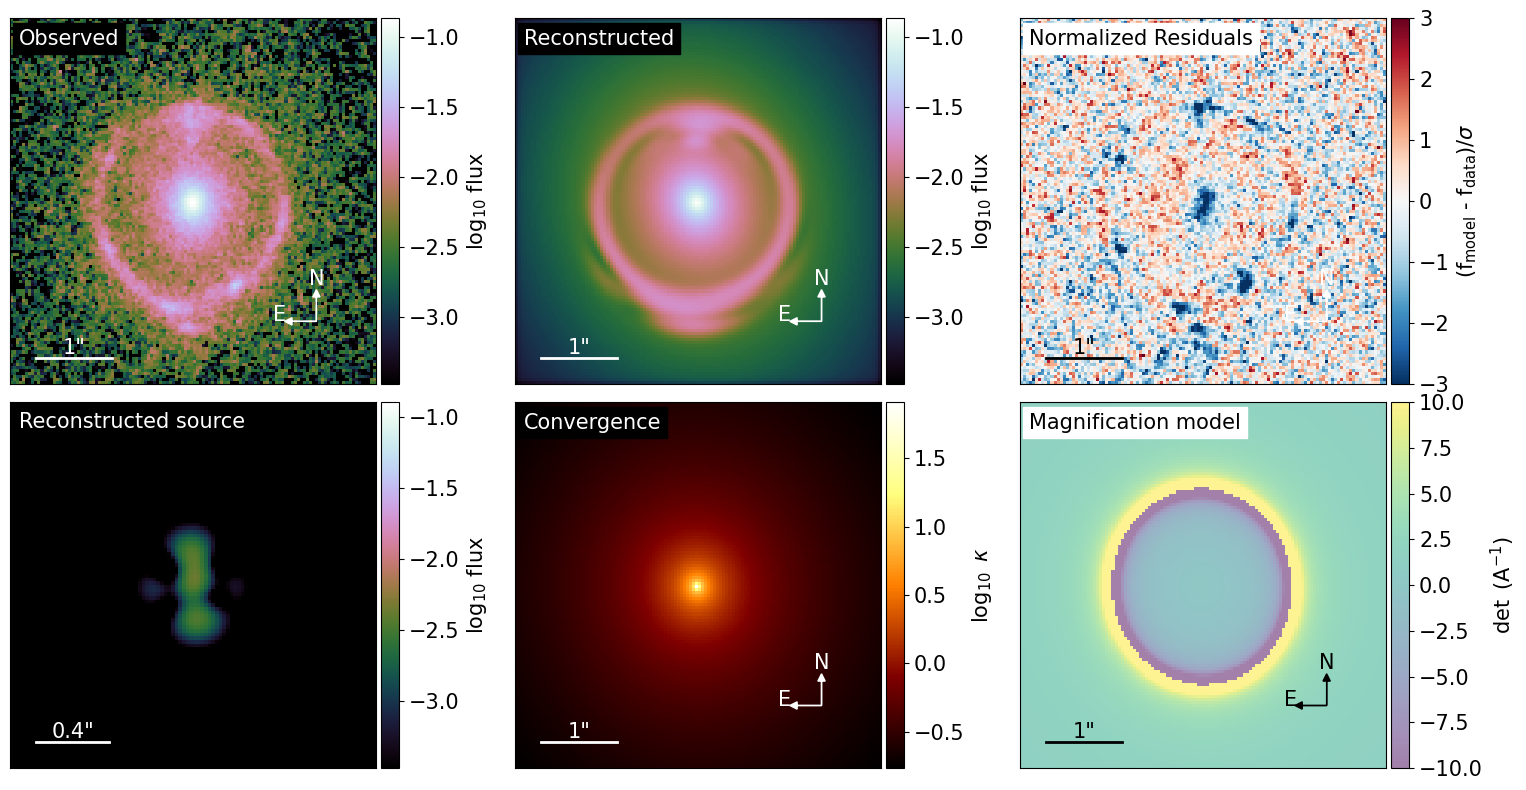

In [ ]:
fig = output.plot_model_overview(lens_name=lens_name, model_id=model_id, reconstruction_id=reconstruction_id)

We only ran a pre-sampling optimization here and did not perform a MCMC sampling. So, the above model is the optimized model that the MCMC sample can initiate from. The `kwargs_result` dictionary of the pre-sampling optimization step can be accessed through `Output.kwargs_result` after loading an output using the `Output.load_output()` method.

In [ ]:
output.load_output(lens_name=lens_name, model_id=model_id)

output.kwargs_result

{'kwargs_lens': [{'theta_E': 1.2318614661307612,
   'gamma': 2.0251159345241114,
   'e1': -0.042334622711789255,
   'e2': 0.008922581227544604,
   'center_x': 0.03203556488887021,
   'center_y': -0.03930654885858535},
  {'gamma_ext': 0.0006336701321928028,
   'psi_ext': 0.0890734748158721,
   'ra_0': 0,
   'dec_0': 0}],
 'kwargs_source': [{'amp': 1,
   'n_max': 4,
   'beta': 0.09494848662900228,
   'center_x': 0.05634419746148085,
   'center_y': -0.2645713056103837}],
 'kwargs_lens_light': [{'amp': 1,
   'R_sersic': 3.0934973130225316,
   'n_sersic': 4.0,
   'e1': -0.07429648885994242,
   'e2': 0.04869389302958316,
   'center_x': 0.03203556488887021,
   'center_y': -0.03930654885858535}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

When necessary, the settings of the model run---that was read out of the 'config_{lens_name}.yaml' file---can be accessed through the `output.model_settings` variable.

In [ ]:
output.model_settings

{'lens_name': 'lens_system2',
 'band': ['F390W'],
 'model': {'lens': ['EPL', 'SHEAR_GAMMA_PSI'],
  'lens_light': ['SERSIC_ELLIPSE'],
  'source_light': ['SHAPELETS']},
 'lens_option': {'centroid_init': [0.04, -0.04]},
 'lens_light_option': {'fix': {'0': {'n_sersic': 4.0}}},
 'source_light_option': {'n_max': [4]},
 'fitting': {'pso': True,
  'pso_settings': {'num_particle': 20, 'num_iteration': 50},
  'sampling': True,
  'sampler': 'emcee',
  'sampler_settings': {'n_burn': 0,
   'n_run': 100,
   'walkerRatio': 2,
   'threadCount': 1,
   'init_samples': None}},
 'numeric_option': {'supersampling_factor': [2]},
 'pixel_size': [0.040000194494947836]}